In [34]:
import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm import LSTM as LSTM1
from models.lstm_proj_diff import LSTM as LSTM2
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [35]:
df_eval = pd.read_parquet("data/tokenized_eval.parquet")
# df_train = pd.read_parquet("data/tokenized_train.parquet").sample(n=100, random_state=42).reset_index(drop=True)

In [37]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [38]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens_50000'].tolist(),
    tokens_tgt=df_eval['pt_tokens_50000'].tolist(),
    invert_src=True
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [39]:
MODELS_TRY = [
    LSTM2
]

In [40]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        if('v32' not in model_name):
           continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        for MODEL_TRY in MODELS_TRY:
            try:
                model = MODEL_TRY(embedding_dim=model_config["embedding_dim"],
                            encoder_bidirectional=model_config["encoder_bidirectional"],
                            encoder_hidden_dim=model_config["encoder_hidden_dim"],
                            encoder_num_layers=model_config["encoder_num_layers"],
                            decoder_hidden_dim=model_config["decoder_hidden_dim"],
                            decoder_num_layers=model_config["decoder_num_layers"],
                            encoder_dropout=model_config["encoder_dropout"],
                            decoder_dropout=model_config["decoder_dropout"],
                            vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                            pad_idx=0)
                model.load_state_dict(torch.load(model_path))
                model.to("cuda" if torch.cuda.is_available() else "cpu")
                model.eval()
                models[model_name] = model
                break
            except RuntimeError as e:
                print(str(e))
                continue

Lendo v32


In [41]:
print(models.keys())

dict_keys(['v32'])


In [43]:
for model_name, model in models.items():

    print(f"Model: {model_name}")

    decoded_outputs = []

    for batch in tqdm(dataloader_eval):

        enc_tokens, _ = batch

        enc_tokens = enc_tokens.to('cuda')
        

        with torch.no_grad():

            outputs = model.predict(
                src=enc_tokens,
                bos_token_id=5,
                eos_token_id=6,
                max_len=64
            )

        decoded_outputs.extend(
            tokenizer.decode_batch(
                outputs.cpu().tolist(),
                skip_special_tokens=True
            )
        )

    df_eval[f'{model_name}_pred'] = decoded_outputs

Model: v32


100%|██████████| 627/627 [01:16<00:00,  8.18it/s]


In [44]:
model_name

'v32'

In [45]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs

,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,batch_size,...,eval_steps,device,desc,name,early_stop_patience,early_stop_min_delta,warmup_steps,max_steps,learning_rate,vocab_size
0,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,cuda,Corrigindo shapes e projeções,v10,5000,0.0,25000.0,200000.0,0.00010,NaN
1,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,cuda,Corrigindo shapes e projeções,v11,5000,0.0,25000.0,200000.0,0.00010,NaN
2,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,cuda,CLippando gradiente e inicializando os params ...,v12,20,0.0,25000.0,400000.0,0.00010,NaN
3,False,768,2048,2048,3,3,0.1,0.1,True,64,...,1000,cuda,Pegando somente a última camada do encoder par...,v13,20,0.0,25000.0,400000.0,0.00010,NaN
4,False,768,2048,2048,3,3,0.1,0.1,True,128,...,1000,cuda,Diminuindo learning rate e aumentando batch size,v14,20,0.0,25000.0,400000.0,0.00005,NaN
5,False,768,2048,2048,3,3,0.1,0.1,True,128,...,1000,cuda,Diminuindo learning rate e aumentando batch size,v15,20,0.0,25000.0,400000.0,0.00005,NaN
6,False,256,1024,1024,1,1,0.1,0.1,True,128,...,1000,cuda,Treinando modelo menor depois de aumentar o ma...,v16,20,0.0,25000.0,200000.0,0.00010,NaN
7,False,256,1024,1024,1,1,0.1,0.1,True,128,...,1000,cuda,Treinando modelo menor depois de aumentar o ma...,v17,20,0.0,25000.0,200000.0,0.00010,NaN
8,False,256,512,512,1,1,0.1,0.1,True,128,...,1000,cuda,Testando outro tokenizador,v18,20,0.0,25000.0,200000.0,0.00010,NaN
9,False,256,512,512,1,1,0.1,0.1,True,128,...,1000,cuda,Testando outra transformação,v19,20,0.0,25000.0,200000.0,0.00010,NaN


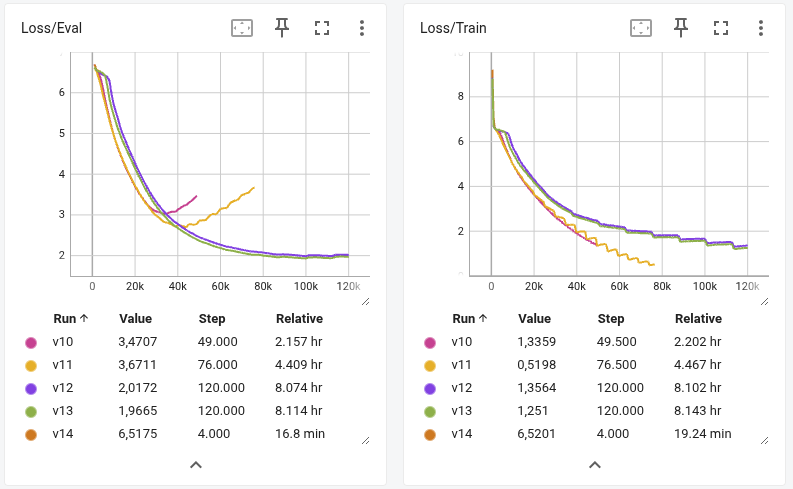

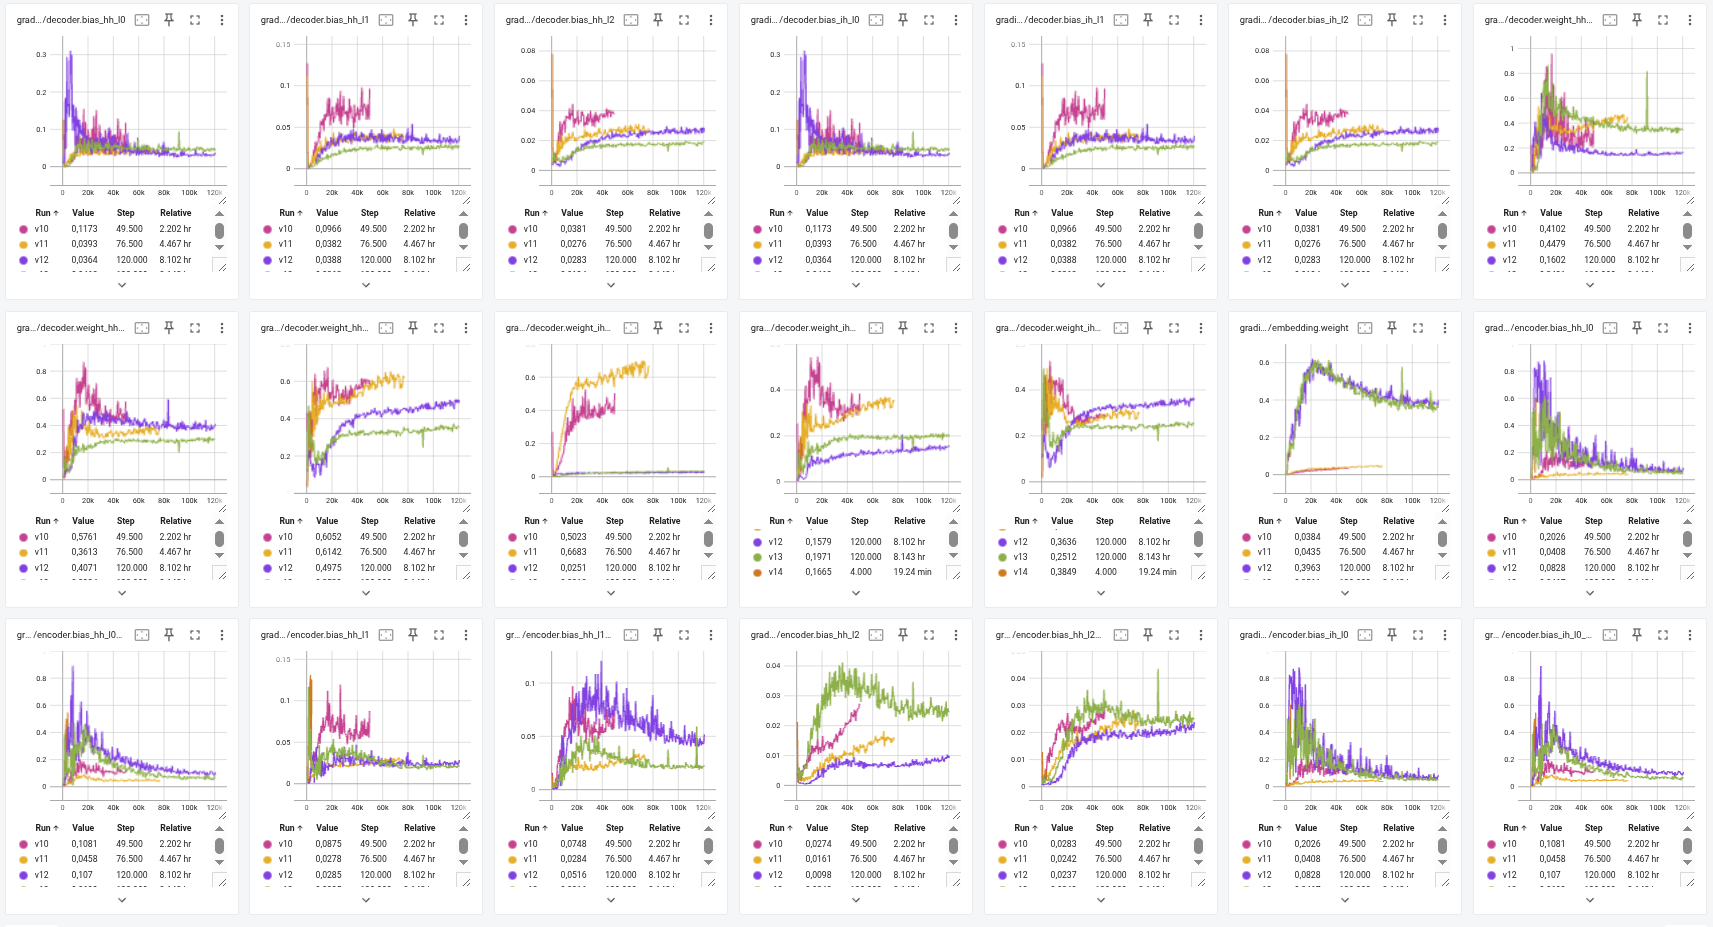

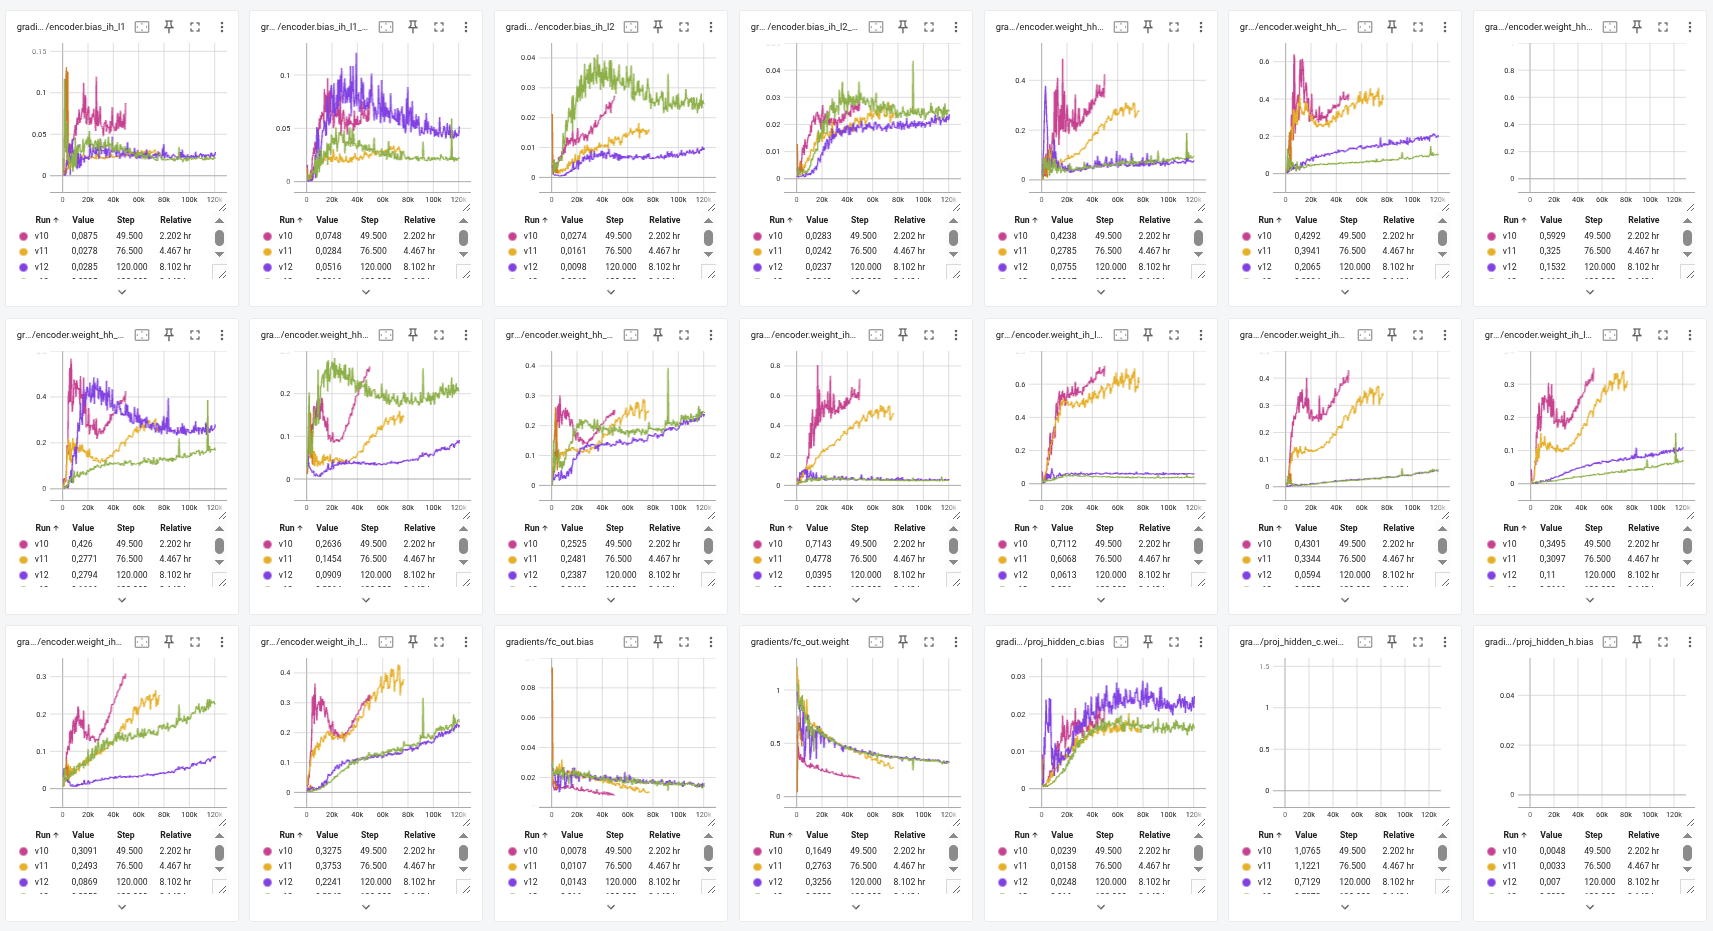

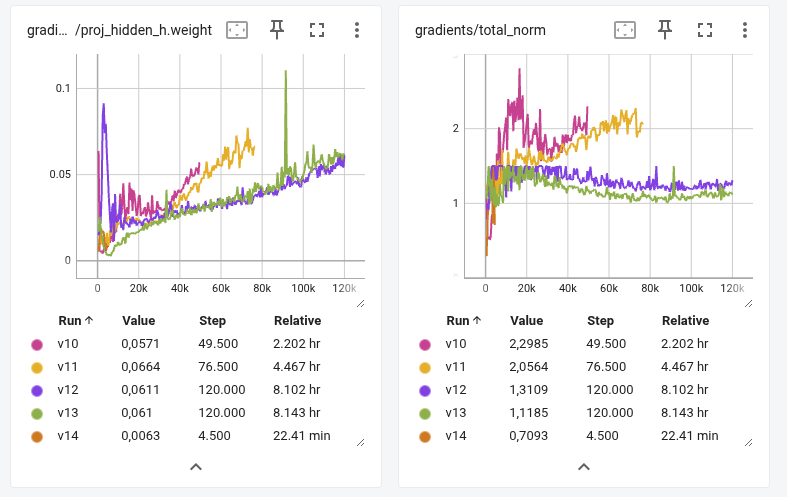

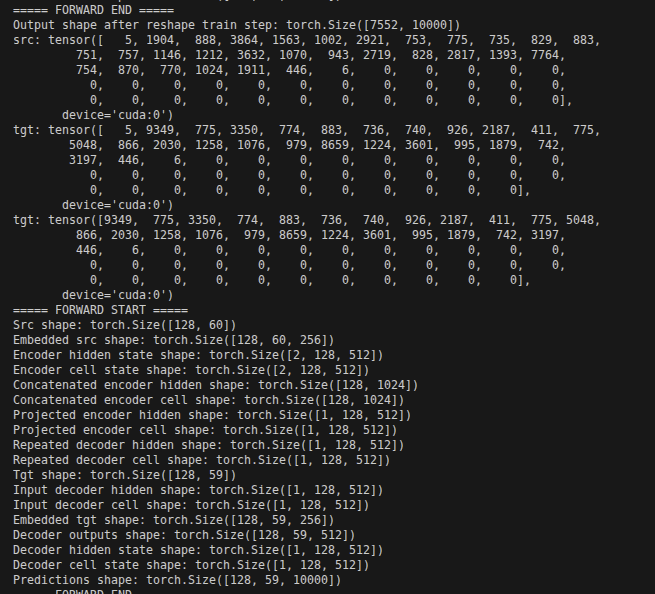

In [47]:
for index in np.random.choice(len(df_eval), size=20, replace=False):
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    for model_test in ['v32_pred']:
        print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: James discovered there was a swiss hill climb event on that weekend... and it was only 200 miles from our hotel.
Português: O james descobriu que havia um evento de corrida de escalada naquele sábado. a apenas 300 quilômetros do nosso hotel.
v32_pred: O hotel , a nossa distância de 200 metros foi ... e o fim de semana em que evento subiu , " kentucky wood " foi encontrado por james ... . . . . . .
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: Now, i understand that you have acquired a slightly different slant on captain root since you called mr. wolfe a mongrel bloodhound.
Português: Agora, eu entendo que você adquiriu uma opinião um pouco diferente sobre o capitão root desde que chamou o sr. wolfe um cão de caça vira-lata.
v32_pred: O sangue de sangue marinado em 37 anos , o nome de vocês que o sr . orland , na categ